<div class="alert alert-block alert-success">
<h2>Sobre este notebook (🇪🇸​):</h2>
<hr>
El objetivo de este notebook es <strong>explorar y comparar el rendimiento de distintos modelos en aprendizaje de ensambles (ensemble learning) para problemas de clasificación y regresión</strong>. Originalmente se desarrolló como parte del máster en ciencia de datos impartido por la UOC, con algunos cambios siendo a posteriori, por lo que solo se encuentra en español.  
<hr>
El dataset utilizado fue proporcionado por la universidad, y consiste en datos simulados cuyo objetivo es únicamente el estudio de las diferentes técnicas exploradas en este proyecto, de las cuales las más relevantes podrían considerarse:
<ol>
<li>SMOTE: para balancear clases en el problema de clasificación</li>
<li>GridSearchCV: para ajuste de hiperparámetros</li>
<li>Cross-validation: para evaluación robusta</li>
<li>Stacking: para combinar modelos y mejorar predicciones</li>
</ol>
<hr>
En conclusión, este notebook es una introducción práctica al uso de modelos combinados en distintos tipos de problemas, y es útil para comparar el rendimiento de distintos algoritmos y comprender su funcionamiento, sin embargo, <strong>se trata con escasa profundidad el análisis de resultados y optimización de features, y no se tratan aspectos como la visualización avanzada o la interpretabilidad de los modelos</strong>, por lo que no se debe entender este notebook como un proyecto end-to-end.
&nbsp;
</div>

<div class="alert alert-block alert-success">
<h2>About this notebook (🇧🇷​):</h2>
<hr>
The goal of this notebook is <strong>to explore and compare the performance of different ensemble-learning models for classification and regression problems</strong>. It was originally developed as part of the Master’s degree in Data Science offered by the UOC (Universitat Oberta de Catalunya), with a few later modifications; consequently, it is available only in Spanish.  
<hr>
The dataset was provided by the university and consists of simulated data intended solely for studying the various techniques explored in this project. The most relevant ones are:
<ol>
<li>SMOTE: to balance classes in the classification problem</li>
<li>GridSearchCV: for hyper-parameter tuning</li>
<li>Cross-validation: for robust evaluation</li>
<li>Stacking: to combine models and improve predictions</li>
</ol>
<hr>
In short, this notebook is a practical introduction to using combined models on different types of problems. It is useful for comparing the performance of various algorithms and understanding how they work. However, <strong>there is only shallow analysis of results and feature optimization, and advanced visualization or model interpretability are not addressed</strong>; therefore, it should not be considered an end-to-end project.
</div>

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, make_scorer, mean_squared_error, mean_absolute_error, r2_score,  accuracy_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier, GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV, cross_val_score
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor, GradientBoostingRegressor, StackingRegressor
from sklearn.linear_model import Ridge

seed = 1245

## Combinación de modelos de Clasificación 

<div class="alert alert-block alert-info">
<h4>Carga y exploración de los datos: </h4>
    En primer lugar cargaremos la base de datos y realizaremos una primera exploración básica.
</div>

In [9]:
df = pd.read_csv('./dataset_clasificacion.csv')

print('\nInformación básica:')
print(df.info())

print('\nValores nulos:')
print(df.isnull().sum())

print('\nInformación de los atributos:')
display(df.describe(include='all'))

print('\nValores únicos por atributo categórico:')
object_columns = df.select_dtypes(include='object').columns
for col in object_columns:
    print(f'Valores únicos en {col}:')
    print(df[col].unique())
    
print('\nOutliers por columna según IQR:')
numeric_columns = df.select_dtypes(include='number').columns
for col in numeric_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)]
    print(f'Outliers en {col}: {outliers.shape[0]}')


Información básica:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 24 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   feature_0   3000 non-null   float64
 1   feature_1   3000 non-null   float64
 2   feature_2   3000 non-null   float64
 3   feature_3   3000 non-null   float64
 4   feature_4   3000 non-null   float64
 5   feature_5   3000 non-null   float64
 6   feature_6   3000 non-null   float64
 7   feature_7   3000 non-null   float64
 8   feature_8   3000 non-null   float64
 9   feature_9   3000 non-null   float64
 10  feature_10  3000 non-null   float64
 11  feature_11  3000 non-null   float64
 12  feature_12  3000 non-null   float64
 13  feature_13  3000 non-null   float64
 14  feature_14  3000 non-null   float64
 15  feature_15  3000 non-null   float64
 16  feature_16  3000 non-null   float64
 17  feature_17  3000 non-null   float64
 18  feature_18  3000 non-null   float64
 19  featur

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_14,feature_15,feature_16,feature_17,feature_18,feature_19,feature_20,feature_21,feature_22,target
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,...,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000,3000,3000.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,4,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CatA_3,TypeY,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,750,866,NaN
mean,-0.167780,0.194072,0.021713,0.565079,0.339354,0.001514,0.214931,0.200799,-0.574093,0.019909,...,1.260273,-0.887056,-0.011400,0.832865,0.018429,-0.013065,-0.019091,NaN,NaN,0.704333
std,1.992783,2.009702,1.988687,1.997788,1.988697,1.005382,1.905222,1.856595,1.850820,0.989841,...,2.845021,3.746794,1.019393,1.750359,0.986256,1.006372,1.400266,NaN,NaN,0.781314
min,-7.430478,-7.017886,-6.903463,-7.177407,-7.157275,-3.596199,-6.640535,-7.127550,-7.571720,-3.278118,...,-12.132204,-13.883680,-3.256573,-9.801035,-3.333694,-3.587773,-5.427674,NaN,NaN,0.000000
25%,-1.537541,-1.085016,-1.288022,-0.698250,-1.032249,-0.668274,-1.106546,-1.020612,-1.809644,-0.655480,...,-0.425860,-3.300002,-0.710163,-0.318462,-0.662098,-0.681826,-0.766254,NaN,NaN,0.000000
50%,-0.233910,0.260095,0.042402,0.616664,0.317372,-0.006355,0.130390,0.237213,-0.666510,0.027168,...,1.359148,-0.913211,-0.011754,0.860290,-0.005160,-0.030038,-0.011659,NaN,NaN,1.000000
75%,1.121515,1.573280,1.419595,1.849444,1.672007,0.653912,1.446997,1.463993,0.517805,0.695489,...,3.089139,1.596332,0.685768,1.964828,0.716549,0.650218,0.687983,NaN,NaN,1.000000



Valores únicos por atributo categórico:
Valores únicos en feature_21:
['CatA_3' 'CatA_2' 'CatA_1' 'CatA_0']
Valores únicos en feature_22:
['TypeX' 'TypeZ' 'TypeW' 'TypeY']

Outliers por columna según IQR:
Outliers en feature_0: 24
Outliers en feature_1: 30
Outliers en feature_2: 20
Outliers en feature_3: 54
Outliers en feature_4: 22
Outliers en feature_5: 29
Outliers en feature_6: 22
Outliers en feature_7: 27
Outliers en feature_8: 48
Outliers en feature_9: 21
Outliers en feature_10: 46
Outliers en feature_11: 47
Outliers en feature_12: 27
Outliers en feature_13: 22
Outliers en feature_14: 55
Outliers en feature_15: 27
Outliers en feature_16: 22
Outliers en feature_17: 42
Outliers en feature_18: 10
Outliers en feature_19: 29
Outliers en feature_20: 168
Outliers en target: 0


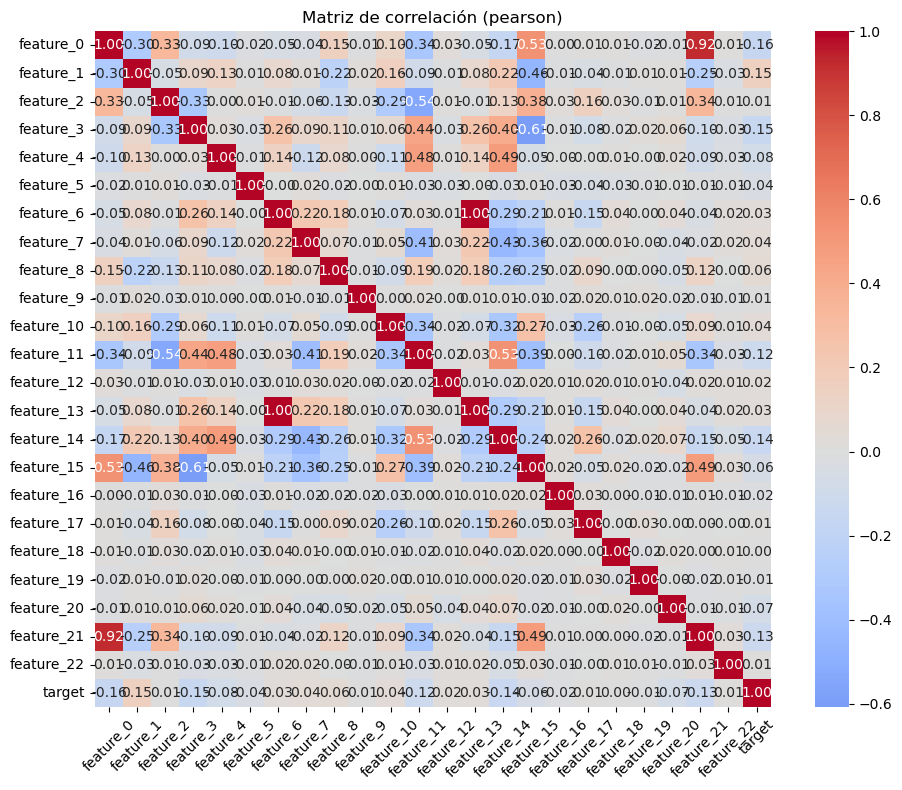


Atributos más correlacionados con target: 


feature_0    -0.157467
feature_3    -0.150950
feature_1     0.149550
feature_14   -0.144089
feature_21   -0.129572
feature_11   -0.118279
feature_4    -0.075103
feature_20   -0.068571
feature_15   -0.059686
feature_8     0.055273
feature_7     0.040921
feature_5    -0.036132
feature_10    0.035143
feature_6     0.030002
feature_13    0.030002
feature_16   -0.019510
feature_12    0.018998
feature_22    0.012475
feature_19   -0.010549
feature_17    0.010047
feature_9     0.006719
feature_2     0.006169
feature_18    0.001890
Name: target, dtype: float64

In [10]:
def get_matrix_corr(df, metodo='pearson'):
    corr = df.corr(method=metodo)
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', center=0, square=True)
    plt.title(f'Matriz de correlación ({metodo})')
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

def label_encode_df(df):
    df_encoded = df.copy()
    for col in df_encoded.select_dtypes(include=['object', 'category']).columns:
        df_encoded[col] = df_encoded[col].astype('category').cat.codes
    return df_encoded

def get_most_correlated(df, col):
    try:
        matriz_corr = df.corr()
        corrs = matriz_corr[col].drop(col)
        corrs = corrs.reindex(corrs.abs().sort_values(ascending=False).index)
        return corrs
    except Exception as error:
        print(error)
        return False

df_enc = label_encode_df(df)
get_matrix_corr(df_enc)
print('\nAtributos más correlacionados con target: ')
display(get_most_correlated(df_enc, 'target'))

<div class="alert alert-block alert-info">
<h4>Feature engineering:</h4>
    Utilizamos one-hot encoding para la transformación de las variables categóricas, de este modo no se asumirá un orden artificial entre los valores. También tendremos que tener en cuenta evitar la multicolinealidad entre variables.
</div>

In [14]:
df_og = df.copy()
df = pd.get_dummies(df_og, drop_first=True, dtype=int)
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 28 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   feature_0          3000 non-null   float64
 1   feature_1          3000 non-null   float64
 2   feature_2          3000 non-null   float64
 3   feature_3          3000 non-null   float64
 4   feature_4          3000 non-null   float64
 5   feature_5          3000 non-null   float64
 6   feature_6          3000 non-null   float64
 7   feature_7          3000 non-null   float64
 8   feature_8          3000 non-null   float64
 9   feature_9          3000 non-null   float64
 10  feature_10         3000 non-null   float64
 11  feature_11         3000 non-null   float64
 12  feature_12         3000 non-null   float64
 13  feature_13         3000 non-null   float64
 14  feature_14         3000 non-null   float64
 15  feature_15         3000 non-null   float64
 16  feature_16         3000 

<div class="alert alert-block alert-info">
<h4>Variable target:</h4>

Realizaremos un análisis de la variable target. Esta solo presenta tres valores de tipo int, 0, 1 y 2, y se distribuyen con una cola hacia la derecha siendo más probables los valores más bajos. La clase 0 acapara casi la mitad de las muestras, mientras que la clase 2 solo un 20%, hemos de tener en cuenta esta distribución ya que un modelo podría sobreajustarse a la clase mayoritaria, por lo que será conveniente aplicar un rebalanceo del dataset mediante oversampling o undersampling o utilizar modelos que permitan ajustar el peso por clase.
</div>

,Count,%
target,,
0,1490,49.67
1,907,30.23
2,603,20.10


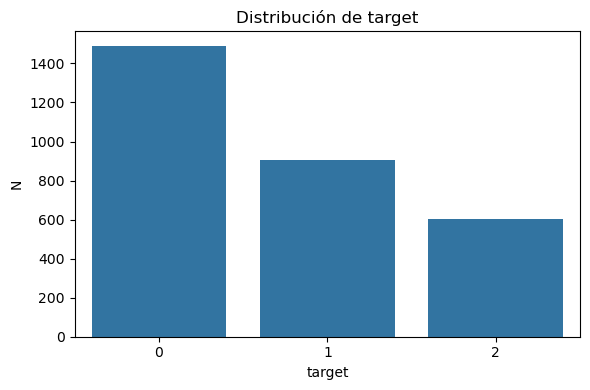

In [18]:
def show_distribution(df, col):
    plt.figure(figsize=(6,4))
    if not pd.api.types.is_numeric_dtype(df[col]) or pd.api.types.is_integer_dtype(df[col]):
        sns.countplot(data=df, x=col)
    else:
        sns.histplot(df[col], bins=30, kde=True)
    plt.title(f'Distribución de {col}')
    plt.xlabel(col)
    plt.ylabel('N')
    plt.tight_layout()
    plt.show()

counts = df['target'].value_counts()
percentages = df['target'].value_counts(normalize=True) * 100
summary = pd.DataFrame({
    'Count': counts,
    '%': percentages.round(2)
})
display(summary)
show_distribution(df, 'target')

<div class="alert alert-block alert-info">
<h4>Variables influyentes:</h4>

Realizaremos un breve análisis de las variables que parecen más potencialmente influyentes en la predicción de la vvariable target.
   
</div>


Atributos más correlacionados con target tras OHE: 


feature_22_TypeX    -0.196842
feature_22_TypeZ     0.159209
feature_0           -0.157467
feature_3           -0.150950
feature_1            0.149550
feature_14          -0.144089
feature_22_TypeY    -0.124254
feature_11          -0.118279
feature_21_CatA_3   -0.106673
feature_4           -0.075103
feature_20          -0.068571
feature_15          -0.059686
feature_8            0.055273
feature_7            0.040921
feature_5           -0.036132
feature_10           0.035143
feature_6            0.030002
feature_13           0.030002
feature_16          -0.019510
feature_12           0.018998
feature_19          -0.010549
feature_17           0.010047
feature_21_CatA_2   -0.007144
feature_9            0.006719
feature_2            0.006169
feature_18           0.001890
feature_21_CatA_1   -0.000246
Name: target, dtype: float64

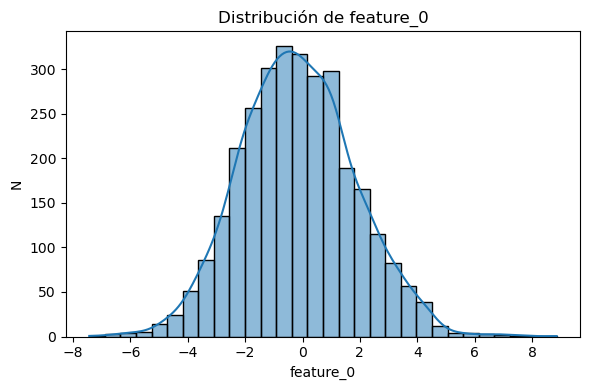

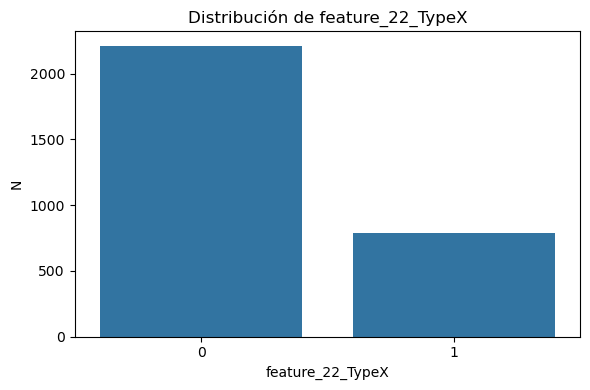

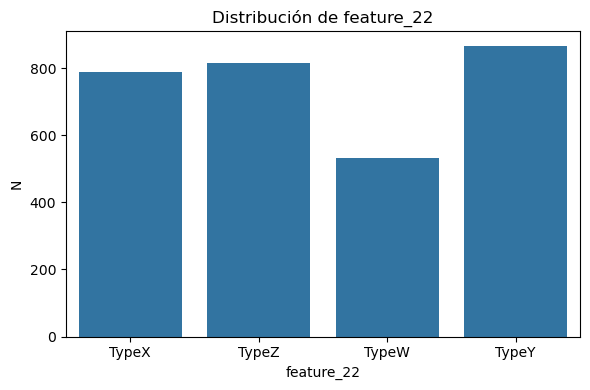

In [22]:
print('\nAtributos más correlacionados con target tras OHE: ')
display(get_most_correlated(df, 'target'))

most_corr_cols = ['feature_0', 'feature_22_TypeX']

for col in most_corr_cols:
    show_distribution(df, col)
show_distribution(df_og, 'feature_22')

<div class="alert alert-block alert-info">
<h4>Rebalanceo de clases:</h4>

Para no reducir demasiado el dataset, aplicamos SMOTE a las clases minoritarias para equiparar la cantidad de muestras. Esto se aplicará solo al conjunto de entrenamiento ya que si no podría producirse una fuga de datos que falsee las predicciones del modelo.
   
</div>

In [26]:
# Dividimos en conjuntos de test, validación y train para evitar fuga de datos
X = df.drop(columns=['target'])
y = df['target']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=seed, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=seed, stratify=y_temp)

# Aplicamos SMOTE solo al conjunto de entrenamiento
smote = SMOTE(random_state=seed)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Distribución original de clases en train:")
print(y_train.value_counts())

print("\nDistribución de clases después de SMOTE:")
print(pd.Series(y_train_res).value_counts())

Distribución original de clases en train:
target
0    1043
1     635
2     422
Name: count, dtype: int64

Distribución de clases después de SMOTE:
target
2    1043
0    1043
1    1043
Name: count, dtype: int64


## Entrenamiento y Evaluación

<div class="alert alert-block alert-info">
<h4>Modelos base:</h4>

Entrenaremos los siguientes modelos base:
   * Regresión Logística (`LogisticRegression`)
   * Árbol de Decisión (`DecisionTreeClassifier`)
   * K vecinos cercanos (`KNeighborsClassifier`)
   * Clasificador Naïves-Bayes (`GaussianNB`)
     
Teniendo en cuenta el contexto de desbalance de clases, la medida más indicativas es la F1 macro ya que en nos indica mejor qué modelo se adapta a los datos (en este caso el knn).
</div>

,Precision Macro,Recall Macro,F1 Macro,Precision Weighted,F1 Weighted,F1 Micro,Accuracy
Logistic Regression,0.579104,0.582361,0.580437,0.624981,0.624415,0.624444,0.624444
Decision Tree,0.593165,0.601393,0.596224,0.629487,0.624671,0.622222,0.622222
K-Nearest Neighbors,0.756463,0.768024,0.758611,0.790144,0.778722,0.775556,0.775556
Gaussian Naive Bayes,0.577808,0.589198,0.578397,0.631687,0.613200,0.604444,0.604444


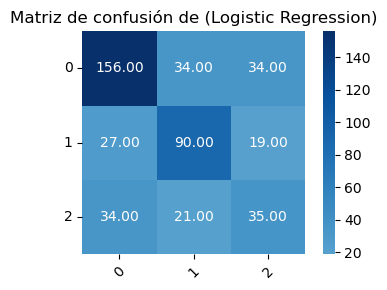

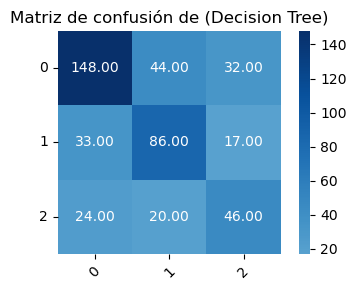

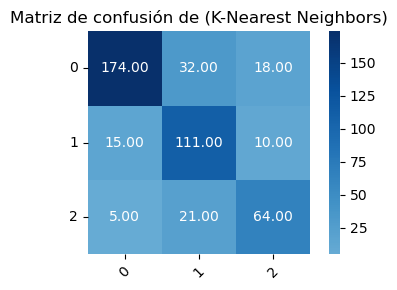

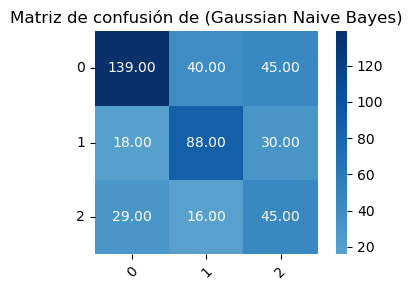

In [31]:
# Modelos a probar
models = {
    "Logistic Regression": LogisticRegression(random_state=seed, max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=seed),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Gaussian Naive Bayes": GaussianNB()
}

results = {}
predictions = {}

# Entrenamos uno de cada y obtenemos métricas
for name, model in models.items():
    model.fit(X_train_res, y_train_res)
    y_pred = model.predict(X_val)
    predictions[name] = y_pred
    
    precision_macro = precision_score(y_val, y_pred, average='macro', zero_division=0)
    recall_macro = recall_score(y_val, y_pred, average='macro', zero_division=0)
    f1_macro = f1_score(y_val, y_pred, average='macro', zero_division=0)
    precision_weighted = precision_score(y_val, y_pred, average='weighted', zero_division=0)
    f1_weighted = f1_score(y_val, y_pred, average='weighted', zero_division=0)
    f1_micro = f1_score(y_val, y_pred, average='micro', zero_division=0)
    accuracy = accuracy_score(y_val, y_pred)
    cm = confusion_matrix(y_val, y_pred)
    
    results[name] = {
        "Precision Macro": precision_macro,
        "Recall Macro": recall_macro,
        "F1 Macro": f1_macro,
        "Precision Weighted": precision_weighted,
        "F1 Weighted": f1_weighted,
        "F1 Micro": f1_micro,
        "Accuracy": accuracy,
        "Confusion Matrix": cm
    }

results_df = pd.DataFrame({k: {kk: vv for kk, vv in v.items() if kk != "Confusion Matrix"} for k, v in results.items()}).T
display(results_df)

for name, metrics in results.items():
    plt.figure(figsize=(4, 3))
    sns.heatmap(metrics['Confusion Matrix'], annot=True, fmt=".2f", cmap='Blues', center=0, square=True)
    plt.title(f'Matriz de confusión de ({name})')
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

<div class="alert alert-block alert-info">
<h4>Bootstrap aggregating - Combinación paralela de clasificadores de base similar: </h4>

Primero entrenaremos un Random Forest Classifier y realizaremos un ajuste de hiperparámetros mediante validación cruzada.
   
</div>

In [36]:
rf = RandomForestClassifier(random_state=seed)

# Parametros para fine tuning
param_grid = {
    'n_estimators': [50, 100, 200, 500], 
    'max_depth': [None, 10, 20, 30],      
    'max_features': ['sqrt', 'log2', None] 
}

# Utilizamos F1 macro como se concluye en el apartado anterior
f1_macro_scorer = make_scorer(f1_score, average='macro')

# Aplicamos grid search y entrenamos con mejores parámetros
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, 
                           scoring=f1_macro_scorer, cv=5, n_jobs=-1, verbose=1)

grid_search.fit(X_train_res, y_train_res)

print("Mejores parámetros encontrados:", grid_search.best_params_)
print("Mejor F1 Macro obtenida:", grid_search.best_score_)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Mejores parámetros encontrados: {'max_depth': 20, 'max_features': 'log2', 'n_estimators': 100}
Mejor F1 Macro obtenida: 0.8802463278613596


<div class="alert alert-block alert-info">
<h4>Feature Importance:</h4>

Random forest no mejora las predicciones de knn para las clases minoritarias, pero sí mejora para la clase mayoritaria, lo que indica que se ha ajustado más a esta. Analizaremos brevemente la importancia de características para el modelo.
   
</div>

F1 Weighted: 0.7502
Accuracy: 0.7578
F1 Macro: 0.7174


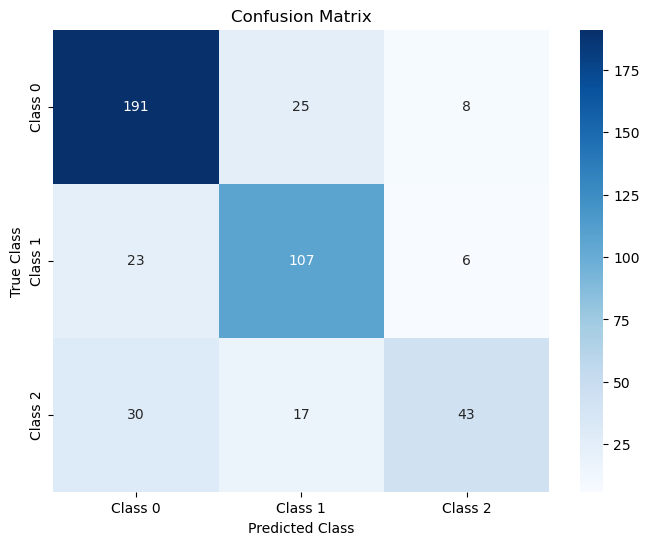

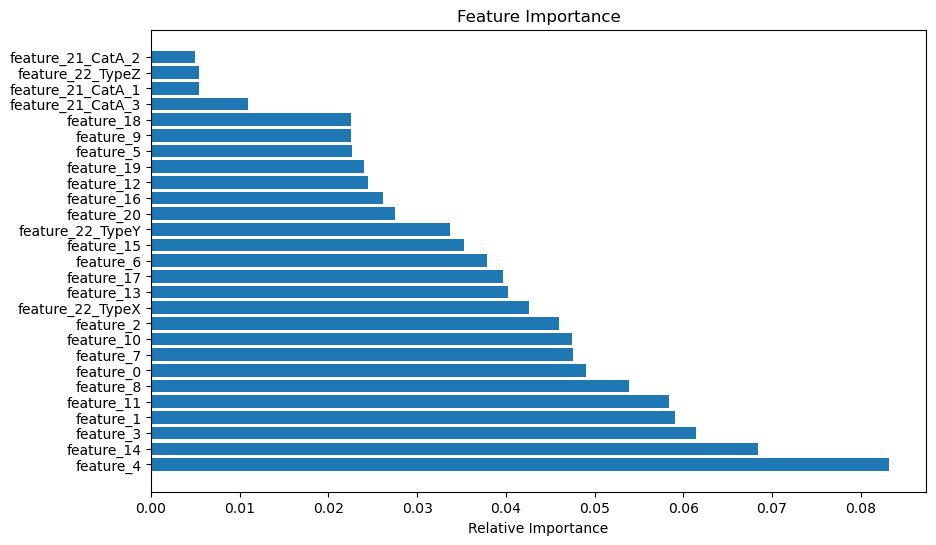

In [40]:
best_rf = grid_search.best_estimator_

# Predecimos con el modelo optimizado
y_pred = best_rf.predict(X_val)

f1_macro_stack = f1_score(y_val, y_pred, average='macro')
f1_weighted = f1_score(y_val, y_pred, average='weighted')
accuracy = accuracy_score(y_val, y_pred)

print(f"F1 Weighted: {f1_weighted:.4f}")
print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Macro: {f1_macro_stack:.4f}")

# Matriz de confusión
conf_matrix = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", 
            xticklabels=['Class 0', 'Class 1', 'Class 2'], yticklabels=['Class 0', 'Class 1', 'Class 2'])
plt.title("Confusion Matrix")
plt.ylabel('True Class')
plt.xlabel('Predicted Class')
plt.show()

# Gráfico de la importancia de las características
importances = best_rf.feature_importances_
indices = importances.argsort()[::-1] 

plt.figure(figsize=(10, 6))
plt.title("Feature Importance")
plt.barh(range(X_train_res.shape[1]), importances[indices], align="center")
plt.yticks(range(X_train_res.shape[1]), X_train_res.columns[indices])
plt.xlabel("Relative Importance")
plt.show()

<div class="alert alert-block alert-info">
<h4>Boosting:</h4>

Implementaremos un GradientBoostingClassifier y realizaremos un ajuste de hiperparámetros, y revisaremos la importancia de características.

En este caso hemos obtenido un F1 de aprox 0.91 en entrenamiento, lo que supone el mejor modelo hasta ahora, con los siguientes parámetros: 'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 300, 'subsample': 0.8. Que gradient boosting haya obtenido los mejores resultados sugiere que es capaz de ajustarse bien a nuestros datos.
   
</div>

In [45]:
# He reducido los parámetros ya que tardaba demasiado en ajustar
gb = GradientBoostingClassifier(random_state=seed)

# Seguimos el mismo procedimiento anterior
param_grid = {
    'n_estimators': [200, 300],
    'learning_rate': [0.1, 0.2],
    'max_depth': [5, 7],
    'subsample': [0.8, 1.0]
}

# usamos F1 macro
f1_macro_scorer = make_scorer(f1_score, average='macro')

# Configuramos GridSearchCV
grid_search_gb = GridSearchCV(
    estimator=gb,
    param_grid=param_grid,
    scoring=f1_macro_scorer,
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search_gb.fit(X_train_res, y_train_res)

print("Mejores hiperparámetros encontrados:", grid_search_gb.best_params_)
print("Mejor F1 Macro obtenido en validación cruzada:", grid_search_gb.best_score_)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Mejores hiperparámetros encontrados: {'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 300, 'subsample': 0.8}
Mejor F1 Macro obtenido en validación cruzada: 0.9081553716552941


F1 Weighted: 0.7932
Accuracy: 0.7978
F1 Macro: 0.7649


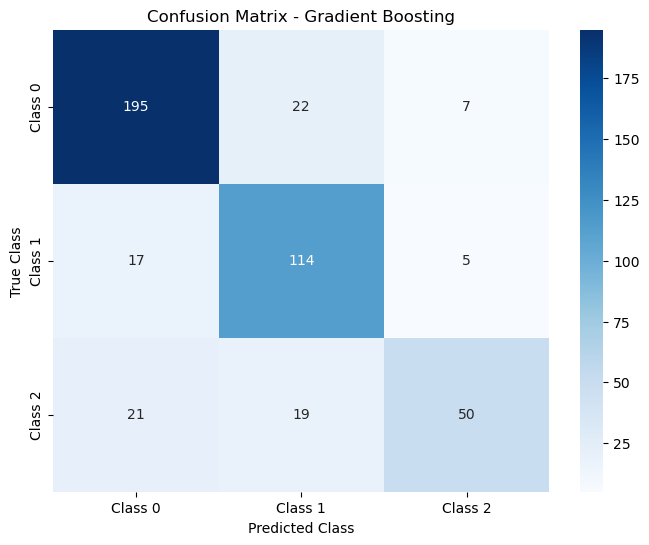

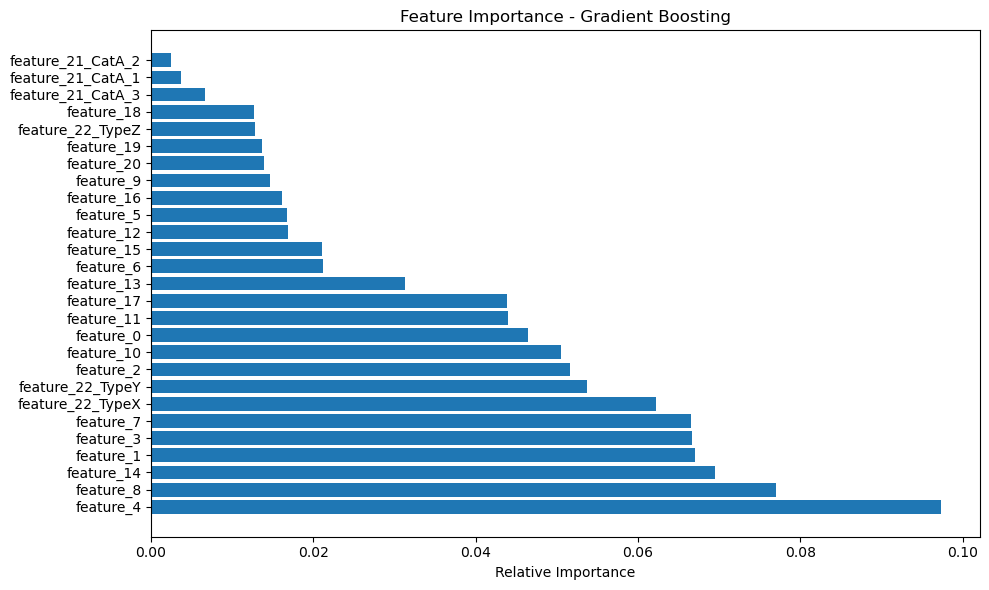

In [49]:
best_gb = grid_search_gb.best_estimator_

y_pred_gb = best_gb.predict(X_val)

f1_macro_stack = f1_score(y_val, y_pred_gb, average='macro')
f1_weighted = f1_score(y_val, y_pred_gb, average='weighted')
accuracy = accuracy_score(y_val, y_pred_gb)

print(f"F1 Weighted: {f1_weighted:.4f}")
print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Macro: {f1_macro_stack:.4f}")

# Matriz de confusión
conf_matrix = confusion_matrix(y_val, y_pred_gb)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=['Class 0', 'Class 1', 'Class 2'], yticklabels=['Class 0', 'Class 1', 'Class 2'])
plt.title("Confusion Matrix - Gradient Boosting")
plt.ylabel('True Class')
plt.xlabel('Predicted Class')
plt.show()

# Importancia de características
importances = best_gb.feature_importances_
indices = importances.argsort()[::-1]

plt.figure(figsize=(10, 6))
plt.title("Feature Importance - Gradient Boosting")
plt.barh(range(X_train_res.shape[1]), importances[indices], align="center")
plt.yticks(range(X_train_res.shape[1]), X_train_res.columns[indices])
plt.xlabel("Relative Importance")
plt.tight_layout()
plt.show()

<div class="alert alert-block alert-info">
<h4>Stacking - Combinación secuencial de clasificadores de base diferente:</h4>

Implementaremos StackingClassifier y un meta-clasificador. El meta clasificador recibirá como entrada las predicciones de los modelos base, y este aprenderá a ponderar las salidas para intentar combinar los puntos fuertes de cada modelo. Aunque no supera el modelo anterior, sí puede competir.
   
</div>

F1 Weighted: 0.7981
Accuracy: 0.8000
F1 Macro - StackingClassifier: 0.7741


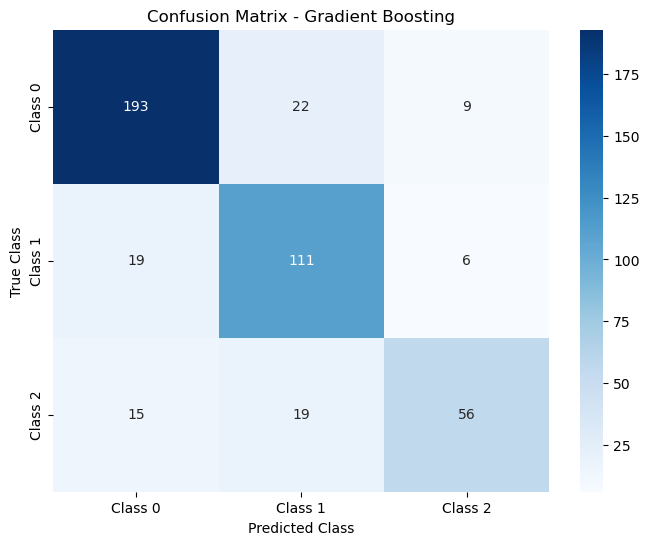

In [54]:
models = [
    ('lr', LogisticRegression(max_iter=1000, random_state=seed)),
    ('dt', DecisionTreeClassifier(random_state=seed)),
    ('knn', KNeighborsClassifier()),
    ('nb', GaussianNB())
]

# Meta-clasificador
meta_model = LogisticRegression(max_iter=1000, random_state=seed)

# Stacking classifier
stacking_model = StackingClassifier(
    estimators=models,
    final_estimator=meta_model,
    cv=5,
    n_jobs=-1,
    passthrough=False
)

# Entrenamos y validamos
stacking_model.fit(X_train_res, y_train_res)

y_pred_stack = stacking_model.predict(X_val)
f1_macro_stack = f1_score(y_val, y_pred_stack, average='macro')
f1_weighted = f1_score(y_val, y_pred_stack, average='weighted')
accuracy = accuracy_score(y_val, y_pred_stack)

print(f"F1 Weighted: {f1_weighted:.4f}")
print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Macro - StackingClassifier: {f1_macro_stack:.4f}")

conf_matrix = confusion_matrix(y_val, y_pred_stack)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=['Class 0', 'Class 1', 'Class 2'], yticklabels=['Class 0', 'Class 1', 'Class 2'])
plt.title("Confusion Matrix - Gradient Boosting")
plt.ylabel('True Class')
plt.xlabel('Predicted Class')
plt.show()

<div class="alert alert-block alert-info">
<h4>Cascading - Combinación secuencial de clasificadores de base diferente:</h4>

Combinaremos en cascada los modelos entrenados anteriormente. El clasificador resultante supera a los modelos anteriores, y requiere menor tiempo de entrenamiento.
   
</div>

Precision Macro: 0.9067
Recall Macro: 0.9069
F1 Macro: 0.9061
Precision Weighted: 0.9171
F1 Weighted: 0.9157
F1 Micro: 0.9156
Accuracy: 0.9156


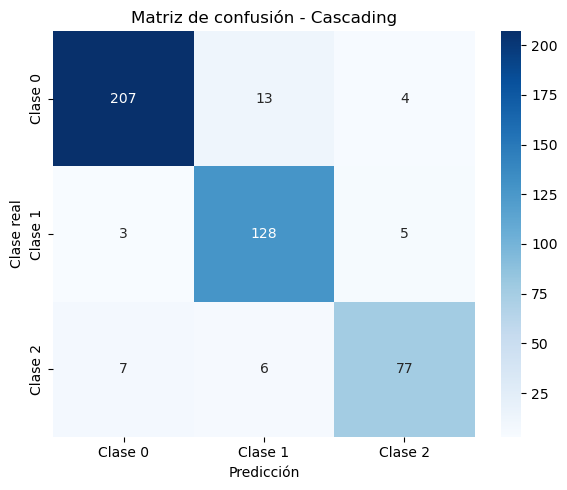

In [59]:
model_1 = LogisticRegression(max_iter=1000, random_state=seed)
model_2 = DecisionTreeClassifier(random_state=seed)
model_3 = KNeighborsClassifier()
model_4 = GaussianNB()

model_1.fit(X_train_res, y_train_res)
model_2.fit(X_train_res, y_train_res)
model_3.fit(X_train_res, y_train_res)
model_4.fit(X_train_res, y_train_res)

y_pred_cascade = np.full_like(y_val, fill_value=-1)

# 1: Regresión Logística
mask_1 = np.full_like(y_val, fill_value=True, dtype=bool)
y_pred_1 = model_1.predict(X_val)
mask_1[y_pred_1 == y_val] = False
y_pred_cascade[y_pred_1 == y_val] = y_pred_1[y_pred_1 == y_val]

# 2: Árbol de Decisión
mask_2 = mask_1.copy()
y_pred_2 = model_2.predict(X_val[mask_2])
mask_2_local = y_pred_2 == y_val[mask_2]
indices_global_2 = np.where(mask_2)[0]
indices_correctos_2 = indices_global_2[mask_2_local]
y_pred_cascade[indices_correctos_2] = y_pred_2[mask_2_local]
mask_2[indices_correctos_2] = False

# 3: KNN
mask_3 = mask_2.copy()
y_pred_3 = model_3.predict(X_val[mask_3])
mask_3_local = y_pred_3 == y_val[mask_3]
indices_global_3 = np.where(mask_3)[0]
indices_correctos_3 = indices_global_3[mask_3_local]
y_pred_cascade[indices_correctos_3] = y_pred_3[mask_3_local]
mask_3[indices_correctos_3] = False

# 4: Naïve Bayes
mask_4 = mask_3.copy()
y_pred_4 = model_4.predict(X_val[mask_4])
indices_global_4 = np.where(mask_4)[0]
y_pred_cascade[indices_global_4] = y_pred_4

# Métricas
precision_macro = precision_score(y_val, y_pred_cascade, average='macro')
recall_macro = recall_score(y_val, y_pred_cascade, average='macro')
f1_macro = f1_score(y_val, y_pred_cascade, average='macro')

precision_weighted = precision_score(y_val, y_pred_cascade, average='weighted')
f1_weighted = f1_score(y_val, y_pred_cascade, average='weighted')
f1_micro = f1_score(y_val, y_pred_cascade, average='micro')

accuracy = accuracy_score(y_val, y_pred_cascade)

print(f"Precision Macro: {precision_macro:.4f}")
print(f"Recall Macro: {recall_macro:.4f}")
print(f"F1 Macro: {f1_macro:.4f}")
print(f"Precision Weighted: {precision_weighted:.4f}")
print(f"F1 Weighted: {f1_weighted:.4f}")
print(f"F1 Micro: {f1_micro:.4f}")
print(f"Accuracy: {accuracy:.4f}")

# Matriz de confusión
cm = confusion_matrix(y_val, y_pred_cascade)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=['Clase 0', 'Clase 1', 'Clase 2'], yticklabels=['Clase 0', 'Clase 1', 'Clase 2'])
plt.xlabel("Predicción")
plt.ylabel("Clase real")
plt.title("Matriz de confusión - Cascading")
plt.tight_layout()
plt.show()

<div class="alert alert-block alert-info">
<h4>Conclusiones:</h4>

Basándonos en la tabla, el mejor modelo obtenido parece ser el de cascading, con mayor valor en todas las métricas. esto indica que este modelo gestiona mejor las complejidades del dataset, seguido por el modelo de stacking.
Las características complicadas del dataset favorecen a aquellos modelos que han podido capturar entonces las relaciones complejas que otros modelos menos flexibles no han podido manejar.
</div>

In [68]:
resultados_clasificacion = pd.DataFrame({
    "Modelo": [
        "Logistic Regression", "Decision Tree", "K-Nearest Neighbors", "Gaussian Naive Bayes",
        "Bagging", "Gradient Boosting", "Stacking", "Cascading"
    ],
    "F1 Macro": [
        0.5804, 0.5962, 0.7586, 0.5784,
        0.7174, 0.7649, 0.7741, 0.8525
    ],
    "F1 Weighted": [
        0.6244, 0.6247, 0.7787, 0.6132,
        0.7502, 0.7932, 0.7981, 0.8675
    ],
    "Accuracy": [
        0.6244, 0.6222, 0.7756, 0.6044,
        0.7578, 0.7978, 0.8000, 0.8689
    ]
})

print("Resumen de rendimiento de modelos de clasificación:")
display(resultados_clasificacion)


Resumen de rendimiento de modelos de clasificación:


,Modelo,F1 Macro,F1 Weighted,Accuracy
0,Logistic Regression,0.5804,0.6244,0.6244
1,Decision Tree,0.5962,0.6247,0.6222
2,K-Nearest Neighbors,0.7586,0.7787,0.7756
3,Gaussian Naive Bayes,0.5784,0.6132,0.6044
4,Bagging,0.7174,0.7502,0.7578
5,Gradient Boosting,0.7649,0.7932,0.7978
6,Stacking,0.7741,0.7981,0.8000
7,Cascading,0.8525,0.8675,0.8689


## Combinación de modelos de Regresión 

<div class="alert alert-block alert-info">
<h4>Carga de datos y análisis:</h4>

El dataset contiene también 3000 registros y 24 variables, con solo una categórica, 22 numéricas y el target. La variable categórica parece tener una alta correlación con el target. No presenta valores nulos, pero existen múltiples outliers en varias variables, incluyendo la variable objetivo, lo que puede afectar a ciertos modelos y requiere un preprocesamiento. La mayoría de variables numéricas tienen baja correlación con el target, sugiriendo que de nuevo tenemos muchas variables redundantes o irrelevantes. Vemos además que a diferencia de en el ejercicio anterior, target es de tipo float y sigue una distribución normal.

</div>


Información básica:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 24 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   feature_0   3000 non-null   float64
 1   feature_1   3000 non-null   float64
 2   feature_2   3000 non-null   float64
 3   feature_3   3000 non-null   float64
 4   feature_4   3000 non-null   float64
 5   feature_5   3000 non-null   float64
 6   feature_6   3000 non-null   float64
 7   feature_7   3000 non-null   float64
 8   feature_8   3000 non-null   float64
 9   feature_9   3000 non-null   float64
 10  feature_10  3000 non-null   float64
 11  feature_11  3000 non-null   float64
 12  feature_12  3000 non-null   float64
 13  feature_13  3000 non-null   float64
 14  feature_14  3000 non-null   float64
 15  feature_15  3000 non-null   float64
 16  feature_16  3000 non-null   float64
 17  feature_17  3000 non-null   float64
 18  feature_18  3000 non-null   float64
 19  featur

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_14,feature_15,feature_16,feature_17,feature_18,feature_19,feature_20,feature_21,feature_22,target
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,...,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000,3000.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,RegCat_2,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,750,NaN
mean,5.021543,5.051891,5.005936,5.028777,5.068402,4.975929,4.906712,5.060034,5.070173,5.023456,...,5.072240,5.046688,5.024344,4.935614,5.008225,5.010288,8.557635,2.504973,NaN,0.100467
std,2.891599,2.936979,2.921469,2.935711,2.917497,2.925945,2.844701,2.979116,2.850197,3.002585,...,2.989869,2.931291,2.882584,2.944228,2.929464,2.905058,3.505216,1.463356,NaN,6.432188
min,0.005197,0.004927,0.002975,0.000678,0.001883,0.001148,0.004678,0.006679,0.004052,0.005569,...,0.000819,0.000922,0.001687,0.000837,0.005082,0.003829,0.116825,-0.196887,NaN,-36.804534
25%,2.545296,2.463100,2.434390,2.451320,2.522927,2.419324,2.446370,2.605828,2.656224,2.411644,...,2.632361,2.573185,2.497222,2.406686,2.493048,2.491462,5.988610,1.214951,NaN,-4.225614
50%,4.999351,5.165146,5.026991,5.114239,5.100698,4.925344,4.900717,5.006263,5.085142,5.041558,...,5.099452,5.064297,5.054047,4.920872,4.937157,5.005381,8.542005,2.498453,NaN,-0.409635
75%,7.508207,7.564666,7.540874,7.483389,7.636131,7.523966,7.277698,7.557672,7.524374,7.553653,...,7.537170,7.545753,7.489901,7.390226,7.495196,7.450939,11.108943,3.764838,NaN,4.114815



Valores únicos por atributo categórico:
Valores únicos en feature_22:
['RegCat_2' 'RegCat_3' 'RegCat_0' 'RegCat_1']

Outliers por columna según IQR:
Outliers en feature_0: 1
Outliers en feature_1: 1
Outliers en feature_2: 1
Outliers en feature_3: 2
Outliers en feature_4: 1
Outliers en feature_5: 1
Outliers en feature_6: 0
Outliers en feature_7: 4
Outliers en feature_8: 0
Outliers en feature_9: 3
Outliers en feature_10: 1
Outliers en feature_11: 3
Outliers en feature_12: 4
Outliers en feature_13: 1
Outliers en feature_14: 3
Outliers en feature_15: 1
Outliers en feature_16: 0
Outliers en feature_17: 1
Outliers en feature_18: 3
Outliers en feature_19: 2
Outliers en feature_20: 2
Outliers en feature_21: 1
Outliers en target: 46


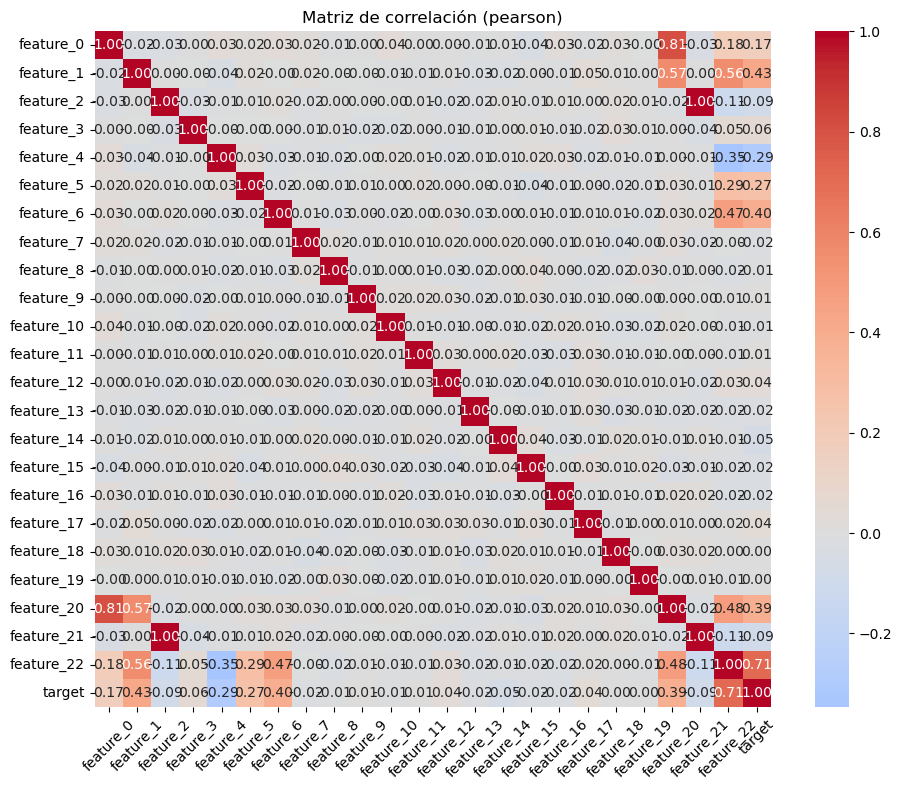


Atributos más correlacionados con target: 


feature_22    0.713689
feature_1     0.429382
feature_6     0.399795
feature_20    0.388812
feature_4    -0.289197
feature_5     0.265111
feature_0     0.165170
feature_21   -0.087701
feature_2    -0.087345
feature_3     0.061624
feature_14   -0.052418
feature_17    0.043243
feature_12    0.039565
feature_15   -0.024760
feature_16   -0.021532
feature_13   -0.019084
feature_7    -0.016074
feature_11    0.013354
feature_9     0.011420
feature_10   -0.011184
feature_8    -0.006570
feature_19    0.004023
feature_18    0.001997
Name: target, dtype: float64

,Count,%
target,,
3.106014,1,0.03
1.079907,1,0.03
0.629085,1,0.03
-2.215966,1,0.03
-7.835409,1,0.03
...,...,...
-5.818633,1,0.03
6.279069,1,0.03
-6.763283,1,0.03


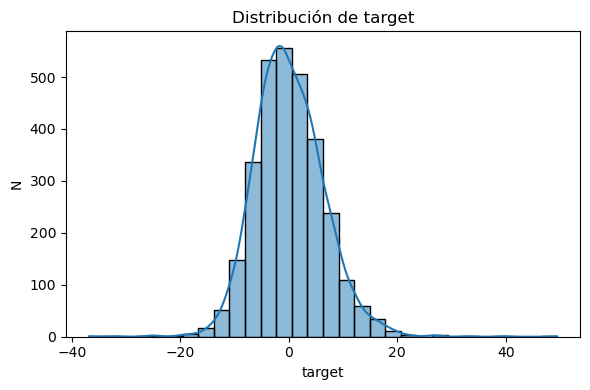

In [73]:
# Seguiré el mismo proceso que en el apartado anterior
df = pd.read_csv('./dataset_regresion_pec4.csv')

# Mostramos la información básica del dataset
print('\nInformación básica:')
print(df.info())

print('\nValores nulos:')
print(df.isnull().sum())

print('\nInformación de los atributos:')
display(df.describe(include='all'))

print('\nValores únicos por atributo categórico:')
object_columns = df.select_dtypes(include='object').columns
for col in object_columns:
    print(f'Valores únicos en {col}:')
    print(df[col].unique())

# Outliers por IQR
print('\nOutliers por columna según IQR:')
numeric_columns = df.select_dtypes(include='number').columns
for col in numeric_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)]
    print(f'Outliers en {col}: {outliers.shape[0]}')

df_enc = label_encode_df(df)
get_matrix_corr(df_enc)
print('\nAtributos más correlacionados con target: ')
display(get_most_correlated(df_enc, 'target'))

counts = df['target'].value_counts()
percentages = df['target'].value_counts(normalize=True) * 100
summary = pd.DataFrame({
    'Count': counts,
    '%': percentages.round(2)
})
display(summary)
show_distribution(df, 'target')

<div class="alert alert-block alert-info">
<h4>One-Hot Encoding:</h4>

</div>

In [77]:
df_og = df.copy()
df = pd.get_dummies(df_og, drop_first=True, dtype=float)
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 26 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   feature_0            3000 non-null   float64
 1   feature_1            3000 non-null   float64
 2   feature_2            3000 non-null   float64
 3   feature_3            3000 non-null   float64
 4   feature_4            3000 non-null   float64
 5   feature_5            3000 non-null   float64
 6   feature_6            3000 non-null   float64
 7   feature_7            3000 non-null   float64
 8   feature_8            3000 non-null   float64
 9   feature_9            3000 non-null   float64
 10  feature_10           3000 non-null   float64
 11  feature_11           3000 non-null   float64
 12  feature_12           3000 non-null   float64
 13  feature_13           3000 non-null   float64
 14  feature_14           3000 non-null   float64
 15  feature_15           3000 non-null   f

<div class="alert alert-block alert-info">
<h4>Correlación con target:</h4>
Vemos que la variable 22 será muy relevante en la predicción de target.
</div>

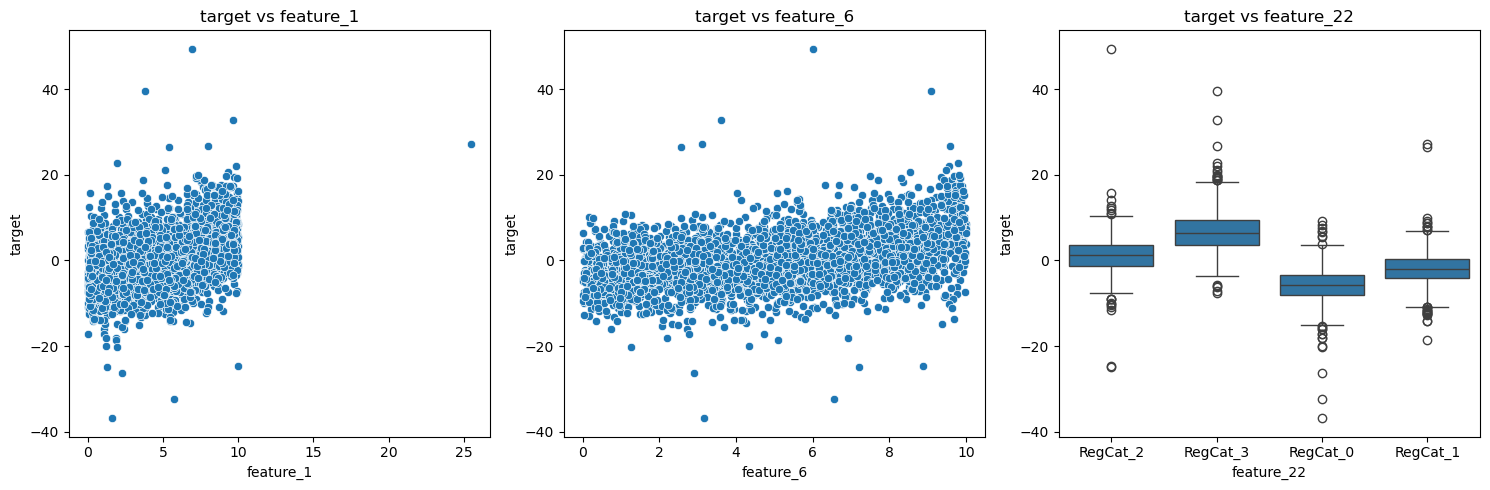

In [81]:
# Seleccionamos las variables más relacionadas con target de la tabla anterior
num_vars = ['feature_1', 'feature_6']
cat_var = 'feature_22'

plt.figure(figsize=(15, 5))

# Scatter plots para variables numéricas vs target
for i, var in enumerate(num_vars, 1):
    plt.subplot(1, 3, i)
    sns.scatterplot(x=df[var], y=df['target'])
    plt.title(f'target vs {var}')
    plt.xlabel(var)
    plt.ylabel('target')

# Boxplot para variable categórica vs target
plt.subplot(1, 3, 3)
sns.boxplot(x=df_og[cat_var], y=df_og['target'])
plt.title(f'target vs {cat_var}')
plt.xlabel(cat_var)
plt.ylabel('target')

plt.tight_layout()
plt.show()

<div class="alert alert-block alert-info">
<h4>Heterocedasticidad:</h4>

Utilizaremos el test de Breusch-Pagan para comprobar si el dataset presenta heterocedasticidad. Como el valor de p es mucho mayor al umbral de 0.05, podemos asumir que este no es el caso.
</div>

In [85]:
# Eliminaremos los outliers mediante IQR
Q1 = df['target'].quantile(0.25)
Q3 = df['target'].quantile(0.75)
IQR = Q3 - Q1

mask = (df['target'] >= Q1 - 1.5 * IQR) & (df['target'] <= Q3 + 1.5 * IQR)
df = df[mask].reset_index(drop=True)


print(f"Filas originales: {len(df_og)}")
print(f"Filas tras eliminar outliers: {len(df)}")

# Separamos en conjuntos de train test y validación
X = df.drop(columns=['target'])
y = df['target']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=seed)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=seed)


Filas originales: 3000
Filas tras eliminar outliers: 2954


In [86]:
# Para comprobar si los datos presentan heterocedasticidad podemos utilizar el test de breusch-pagan
# Ajustamos modelo con statsmodels para obtener residuos
X_sm = sm.add_constant(X_val)  # Añadir intercepto
model_sm = sm.OLS(y_val, X_sm).fit()
residuals = model_sm.resid

# Test de Breusch-Pagan
test = het_breuschpagan(residuals, model_sm.model.exog)
labels = ['Lagrange multiplier statistic', 'p-value', 'f-value', 'f p-value']
print(dict(zip(labels, test)))

{'Lagrange multiplier statistic': 15.61166847528512, 'p-value': 0.9259033653614663, 'f-value': 0.6092881133155069, 'f p-value': 0.9323093874305318}


<div class="alert alert-block alert-info">
<h4>Entrenamiento y Evaluación de Modelos Base:</h4>
Implementaremos los siguientes modelos:
    
   * Regresión Lineal (`LinearRegression`)
   * Árbol de Decisión regresor (`DecisionTreeRegressor`)
   
</div>

In [91]:
lr = LinearRegression()
dt = DecisionTreeRegressor(random_state=seed)

# Definiremos las métricas personalizadas para cross_val_score
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

rmse_scorer = make_scorer(rmse, greater_is_better=False)  # Negativo para cross_val_score

mae_scorer = make_scorer(mean_absolute_error, greater_is_better=False)
r2_scorer = make_scorer(r2_score)

# Función que usaremos para evaluar el modelo y obtener métricas
def evaluate_model(model, X, y):
    neg_rmse_scores = cross_val_score(model, X, y, cv=5, scoring=rmse_scorer, n_jobs=-1)
    neg_mae_scores = cross_val_score(model, X, y, cv=5, scoring=mae_scorer, n_jobs=-1)
    r2_scores = cross_val_score(model, X, y, cv=5, scoring=r2_scorer, n_jobs=-1)

    rmse_scores = -neg_rmse_scores
    mae_scores = -neg_mae_scores

    print(f"Model: {model.__class__.__name__}")
    print(f"Average RMSE: {rmse_scores.mean():.4f}")
    print(f"Average MAE: {mae_scores.mean():.4f}")
    print(f"Average R2: {r2_scores.mean():.4f}")
    print("-" * 30)
    return rmse_scores.mean(), mae_scores.mean(), r2_scores.mean()

# Evaluamos los modelos
rmse_lr, mae_lr, r2_lr = evaluate_model(lr, X_train, y_train)
rmse_dt, mae_dt, r2_dt = evaluate_model(dt, X_train, y_train)

rmse_lr, mae_lr, r2_lr = evaluate_model(lr, X_val, y_val)
rmse_dt, mae_dt, r2_dt = evaluate_model(dt, X_val, y_val)

Model: LinearRegression
Average RMSE: 3.8727
Average MAE: 2.9449
Average R2: 0.5591
------------------------------
Model: DecisionTreeRegressor
Average RMSE: 5.4461
Average MAE: 4.2531
Average R2: 0.1275
------------------------------
Model: LinearRegression
Average RMSE: 3.6789
Average MAE: 2.9191
Average R2: 0.5921
------------------------------
Model: DecisionTreeRegressor
Average RMSE: 5.1583
Average MAE: 4.1556
Average R2: 0.1879
------------------------------


<div class="alert alert-block alert-info">
<h4>Combinación paralela de clasificadores de base similar:</h4>

Implementaremos un gradient boosting regressor. Vemos que no se consigue una mejora significativa.
   
</div>

In [96]:
# Buscamos parámetros con gridsearch como en el ejercicio anterior
gbr = GradientBoostingRegressor(random_state=seed)

param_grid = {
    'n_estimators': [25, 50, 100],
    'max_depth': [3, 5, 7],
    'max_features': ['sqrt', 'log2', None]
}

grid_search = GridSearchCV(
    estimator=gbr,
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error',
    cv=5,
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)
evaluate_model(gbr, X_train, y_train)

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Model: GradientBoostingRegressor
Average RMSE: 3.8953
Average MAE: 2.9860
Average R2: 0.5537
------------------------------


(3.8953109719703094, 2.9860155714285703, 0.5537498158099817)

<div class="alert alert-block alert-info">
<h4>Validación y análisis de resultados:</h4>

Validamos el modelo con las métricas RMSE, MAE y R² y generamos dos gráficos clave:
   * Gráfico de Valores Predichos vs. Valores Reales.
   * Gráfico de Residuos (Predichos - Reales) vs. Valores Predichos.

Podemos ver en el gráfico que aunque hay una tendencia a lo largo de la diagonal, hay mucha dispersión en los valores. Aunque se predice bien para muchos valores, el modelo tiene espacio de mejora. En cuanto a la relación de las variables, vemos que se mantiene la relación con la variable categórica que vimos anteriormente.
   
</div>

Model: GradientBoostingRegressor
Average RMSE: 3.7940
Average MAE: 3.0365
Average R2: 0.5643
------------------------------


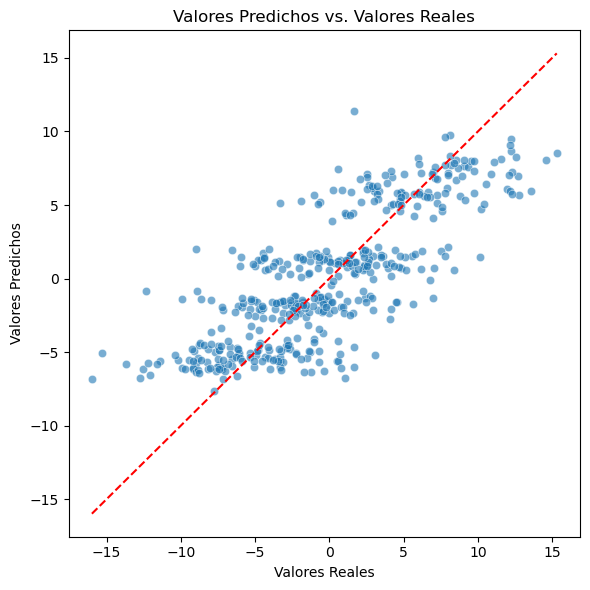

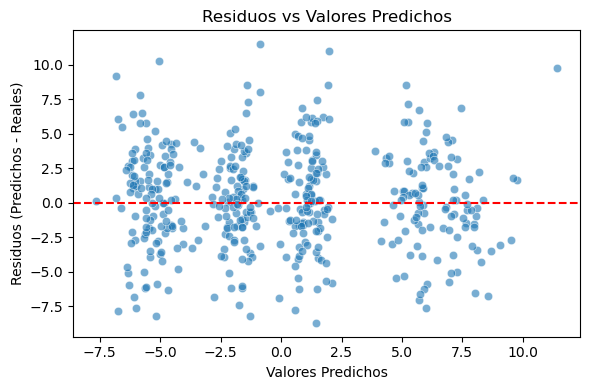

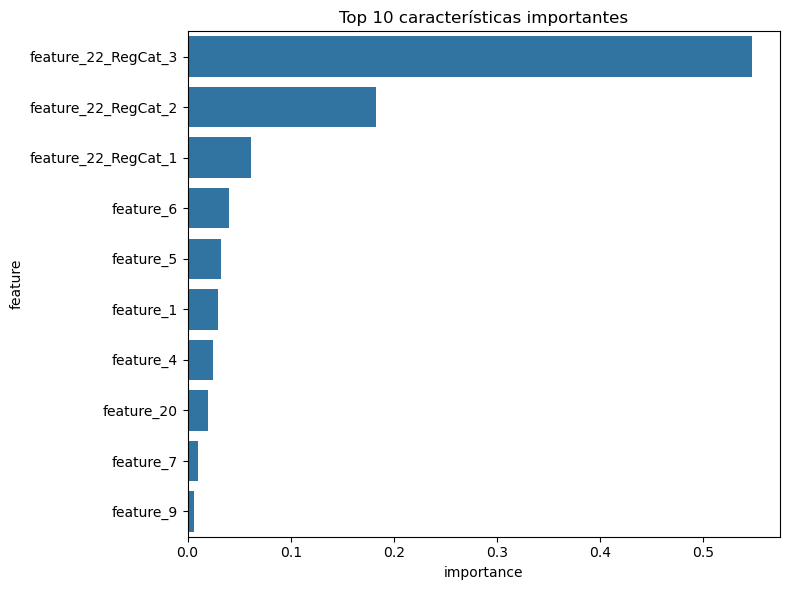

In [100]:
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_val)

evaluate_model(best_model, X_val, y_val)

# Gráfico 1: Valores predichos vs valores reales
plt.figure(figsize=(6,6))
sns.scatterplot(x=y_val, y=y_pred, alpha=0.6)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--') 
plt.xlabel('Valores Reales')
plt.ylabel('Valores Predichos')
plt.title('Valores Predichos vs. Valores Reales')
plt.tight_layout()
plt.show()

# Gráfico 2: Residuos vs valores predichos
residuals = y_pred - y_val
plt.figure(figsize=(6,4))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Valores Predichos')
plt.ylabel('Residuos (Predichos - Reales)')
plt.title('Residuos vs Valores Predichos')
plt.tight_layout()
plt.show()

# Importancia de las variables
importances = best_model.feature_importances_
features = X_val.columns
fi_df = pd.DataFrame({'feature': features, 'importance': importances}).sort_values(by='importance', ascending=False)
plt.figure(figsize=(8,6))
sns.barplot(data=fi_df.head(10), x='importance', y='feature')
plt.title('Top 10 características importantes')
plt.tight_layout()
plt.show()



<div class="alert alert-block alert-info">
<h4>Combinación secuencial de clasificadores de base diferente:</h4>
   
Combinaremos el modelo con un knn por basarse en la proximidad en el espacio de características, ya que puede capturar patrones no previstos, y adicionalmente he preferido escoger un modelo diferente a los previos. Utilizaremos también ridge como meta regresor para prevenir el sobreajuste.
Vemos que el modelo mejora respecto a los anteriores evaluando con el conjunto de validación, pero las métricas son similares y no se aprecia una mejora realmente significativa.
   
</div>

In [105]:
base_models = [
    ('lr', LinearRegression()),
    ('dt', DecisionTreeRegressor(random_state=seed)),
    ('knn', KNeighborsRegressor())
]

# Creamos el meta-regresor (ridge)
meta_model = Ridge()

# Modelo en stacking
stack_model = StackingRegressor(
    estimators=base_models,
    final_estimator=meta_model,
    cv=5,
    n_jobs=-1
)

# Entrenamos
stack_model.fit(X_train, y_train)
y_pred = stack_model.predict(X_val)

# Métricas
evaluate_model(stack_model, X_train, y_train)
evaluate_model(stack_model, X_val, y_val)

Model: StackingRegressor
Average RMSE: 3.8636
Average MAE: 2.9324
Average R2: 0.5612
------------------------------
Model: StackingRegressor
Average RMSE: 3.6725
Average MAE: 2.9256
Average R2: 0.5942
------------------------------


(3.672474794086553, 2.9255948139124244, 0.5941804607010915)

<div class="alert alert-block alert-info">
<h4>Comparación Global y Conclusiones:</h4>

Viendo la tabla resumen podemos ver que el mejor modelo es el de stacking, al obtener mayor r2 y menor error, esto concuerda con su capacidad de combinar distintos algoritmos y aprovechar sus distintas fortalezas. Sin embargo, obtiene unas métricas prácticamente iguales a las del modelo liner regression, por lo que podemos intuir que los modelos no son complementarios y el stacking no ganaría mucho de combinarlos.

</div>

In [110]:
resultados_regresion = pd.DataFrame({
    "Modelo": ["Linear Regression", "Decision Tree", "Gradient Boosting", "Stacking"],
    "RMSE": [3.68, 5.15, 3.79, 3.67],
    "MAE": [2.92, 4.15, 3.03, 2.93],
    "R²": [0.5921, 0.1879, 0.5643, 0.5942]
})

print("Resumen de rendimiento de modelos de regresión:")
display(resultados_regresion)

Resumen de rendimiento de modelos de regresión:


,Modelo,RMSE,MAE,R²
0,Linear Regression,3.68,2.92,0.5921
1,Decision Tree,5.15,4.15,0.1879
2,Gradient Boosting,3.79,3.03,0.5643
3,Stacking,3.67,2.93,0.5942
